In [34]:
# --- Core libraries ---
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
from shapely.geometry import Point
from tabulate import tabulate
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# --- Scikit-learn: model training, preprocessing, CV, evaluation ---
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
    GridSearchCV
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    balanced_accuracy_score,
    roc_auc_score,
    make_scorer,
    ConfusionMatrixDisplay
)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import BallTree

# --- XGBoost ---
from xgboost import XGBRegressor, plot_tree, plot_importance
import xgboost as xgb # Optional: useful for checking version

# --- Other ---
from haversine import haversine
import scipy.stats as stats
import gstools as gs #variogram modeling
from sklearn.metrics import pairwise_distances # for distance calculations
from scipy.cluster.hierarchy import linkage, dendrogram #for hierarchical clustering dendrogram


In [35]:
print("Current working directory:", os.getcwd())

#load in 
df_raw = pd.read_csv("../../../../data/finaldatasets/testdata/XGBoost.csv")  # for variogram, etc.
df = df_raw.copy()  # working copy for feature engineering + model prep
print(list(df.columns))



Current working directory: /home/sebastian-dohne/Documents/FinalProject/code/analysis/kagglefeatureengineering/xgboost
['id', 'Data.ID', 'Location', 'State.Region.County.Province', 'Country', 'Continent', 'Latitude..N.S.', 'Longitude..E.W.', 'Conversion.for.latitude', 'Conversion.for.longitude', 'Location.source', 'Observation.period', 'Wheat.Type', 'Crop.variety', 'Tillage.type', 'Treatment', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Mean.annual.precipitation..mm.', 'Soil.type', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.rate..kg.N.ha.1.', 'P.rate..kg.P.ha.1.', 'Pest.prescence....64', 'rainfed_start_date', 'irr_start_date', 'start_date', 'Soil_N', 'pr_irrigated', 'AEZ', 'Elevation', 'temp1', 'temp2', 'temp3', 'temp4', 'temp5', 'temp6', 'temp7', 'temp8', 'temp9', 'prc1', 'prc2', 'prc3', 'prc4', 'prc5', 'prc6', 'prc7', 'prc8', 'prc9', 'Irrigation.mm_clean', 'irrigation_applied', 'harvest_dayofyear', 'Treatment_Category', 'gdp', 'hdi', 'yea

/tmp/ipykernel_137584/3346672248.py:4: DtypeWarning: Columns (6,7,13,14,15,19,27,56) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("../../../../data/finaldatasets/testdata/XGBoost.csv")  # for variogram, etc.


In [36]:
def summarize_dataframe(df):
    """
    Prints a summary of the DataFrame's columns including:
    - dtype
    - count of non-null values
    - % completeness
    - number of unique values
    Output is printed in GitHub-style markdown table.
    """
    def summarize_column(col_data):
        numeric_data = pd.to_numeric(col_data, errors='coerce')
        is_numeric = numeric_data.notna().sum() > 0
        return {
            "dtype": col_data.dtype,
            "count": col_data.notna().sum(),
            "pct_complete": round(col_data.notna().mean() * 100, 1),
            "n_unique": col_data.nunique(dropna=True)
        }

    summary_long = (
        pd.DataFrame([
            {"variable": col, **summarize_column(df[col])}
            for col in df.columns
        ])
        .sort_values(by="pct_complete", ascending=False)
        .reset_index(drop=True)
    )

    print(tabulate(summary_long, headers="keys", tablefmt="github", showindex=False))

In [37]:
# Define groups of columns to drop
LOCATION_COLS = [
    "id", "Data.ID", "Location", "State.Region.County.Province", "Country", "Continent",
    "Latitude..N.S.", "Longitude..E.W.",
    "Location.source", "Observation.period", "X", "Y", "unit_code", "Year_x"
]

# "Conversion.for.latitude", "Conversion.for.longitude"
HIGH_CARDINALITY_COLS = [
    "Treatment.type", "Emissions..yes.no.",
    "Irrigation..mm.", "Harvesting.date.1","Pest.severity.score.......66",
    "Agricultural_Use_–_Other_Pesticides_nes_(t)","Agricultural_Use_–_Rodenticides_(t)", 
    "irr_end_date", "end_date", "rainfed_end_date"
]


COLLINEAR_COLS = [
    "harvest_month", "harvest_date_clean", "harvest_week",
    "Planting.date", "Planting_Month", "Planting.date.1", "Planting_Week"
]

# These columns are used for testing purposes
TESTCOLUMNS = [
    "Crop.variety", "N.type", "gdp", "hdi", "P.rate..kg.P.ha.1.",
    "dryspells(5days)", "drydays(annualsum)", "irr_start_date", "rainfed_start_date",
    "Mean.annual.precipitation..mm.", "irrigation_applied", "Pest.prescence....64",
    "Irrigation.mm_clean", "Soil.type", "harvest_dayofyear", "Treatment_Category",
    "Tillage.type", "Treatment", "Mean.annual.temperature..Â.C.", "start_date"
]


# Combine all columns to drop into a single set (to avoid duplicates)
COLUMNS_TO_DROP = set(LOCATION_COLS + HIGH_CARDINALITY_COLS + COLLINEAR_COLS + TESTCOLUMNS)

# Drop all listed columns if they exist in the DataFrame
df_cleaned = df.drop(columns=[col for col in COLUMNS_TO_DROP if col in df.columns])

# Optional: Review dropped and remaining columns
print("Original shape:", df.shape)
print("Shape after dropping:", df_cleaned.shape)
print("Dropped columns:", [col for col in COLUMNS_TO_DROP if col in df.columns])
print("Remaining columns:", df_cleaned.columns.tolist())

# Drop columns with less than 20% completeness
df_cleaned = df_cleaned.loc[:, df_cleaned.count() / len(df_cleaned) >= 0.2]

# Drop unnamed columns and rows with NaN in the target variable
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]
df_cleaned = df_cleaned.dropna(subset=["Grain.yield..tons.ha.1."])


Original shape: (69430, 69)
Shape after dropping: (69430, 39)
Dropped columns: ['irrigation_applied', 'Longitude..E.W.', 'Continent', 'Observation.period', 'rainfed_start_date', 'dryspells(5days)', 'start_date', 'Latitude..N.S.', 'State.Region.County.Province', 'Tillage.type', 'hdi', 'Pest.prescence....64', 'Country', 'Mean.annual.temperature..Â.C.', 'Data.ID', 'id', 'irr_start_date', 'Location', 'Location.source', 'Crop.variety', 'drydays(annualsum)', 'Year_x', 'harvest_dayofyear', 'Treatment_Category', 'Soil.type', 'Irrigation.mm_clean', 'P.rate..kg.P.ha.1.', 'Mean.annual.precipitation..mm.', 'gdp', 'Treatment']
Remaining columns: ['Conversion.for.latitude', 'Conversion.for.longitude', 'Wheat.Type', 'Grain.yield..tons.ha.1.', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.rate..kg.N.ha.1.', 'Soil_N', 'pr_irrigated', 'AEZ', 'Elevation', 'temp1', 'temp2', 'temp3', 'temp4', 'temp5', 'temp6', 'temp7', 'temp8', 'temp9', 'prc1', 'prc2', 'prc3', 'prc4', 'prc5', 'prc

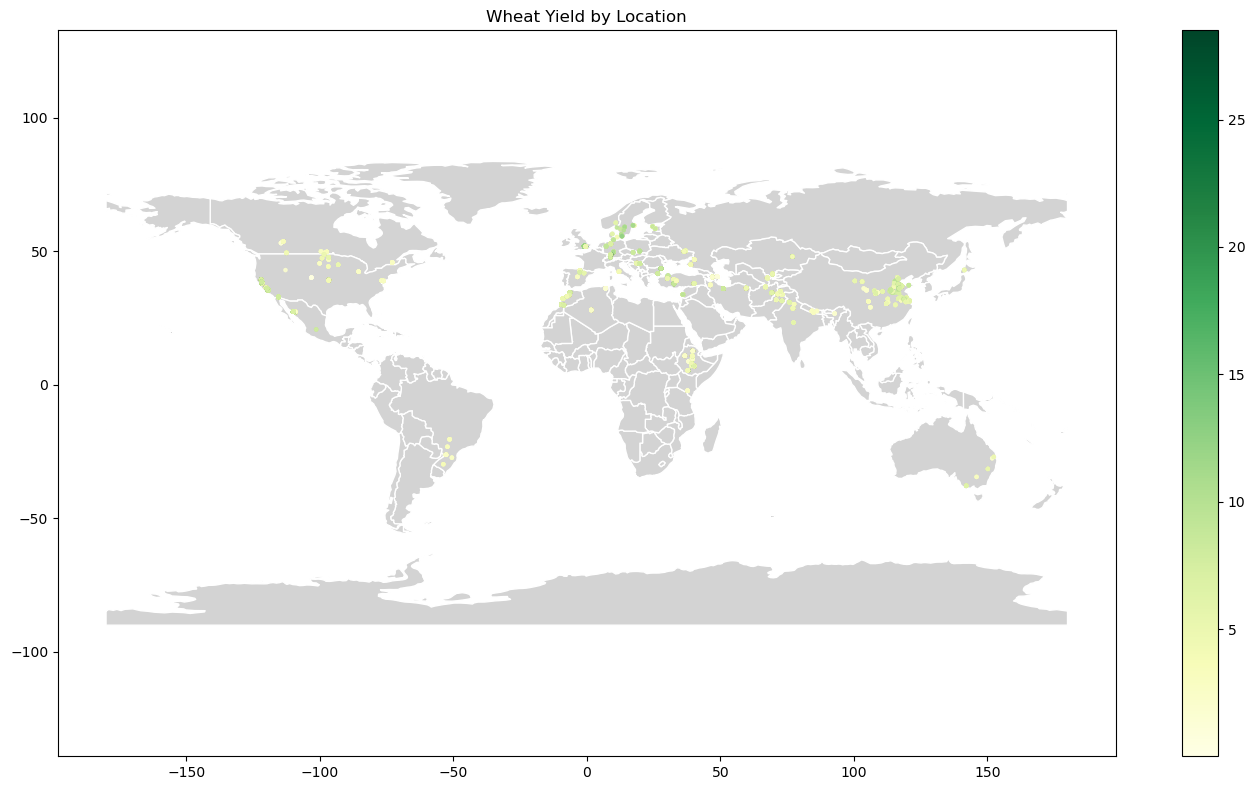

In [40]:
# Step 1: Create GeoDataFrame from your data
gdf = gpd.GeoDataFrame(
    df_cleaned.dropna(subset=['Conversion.for.latitude', 'Conversion.for.longitude', 'Grain.yield..tons.ha.1.']),  # drop rows missing coords or yield
    geometry=gpd.points_from_xy(
        df_cleaned['Conversion.for.longitude'],
        df_cleaned['Conversion.for.latitude']
    ),
    crs="EPSG:4326"
)

# Step 2: Load world basemap from Natural Earth (high-res via GitHub)
world = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
)

# Step 3: Plot yield values on map
ax = world.plot(figsize=(14, 8), color='lightgray', edgecolor='white')
gdf.plot(ax=ax, column='Grain.yield..tons.ha.1.', cmap='YlGn', markersize=5, legend=True, alpha=0.6)

plt.title("Wheat Yield by Location")
plt.axis('equal')
plt.tight_layout()
plt.show()

##### Create a mask for NA 

In [41]:
# Approximate bounding box for North America
na_mask = (
    (df_cleaned['Conversion.for.latitude'] >= 7) &   # Southern Mexico / Central America
    (df_cleaned['Conversion.for.latitude'] <= 84) &  # Top of Canada
    (df_cleaned['Conversion.for.longitude'] >= -170) &  # Western Alaska
    (df_cleaned['Conversion.for.longitude'] <= -40)     # Eastern Canada / Atlantic
)

df_cleaned = df_cleaned[na_mask].copy()


In [42]:
#see how many labels there are before doing rf: 
df_cleaned.select_dtypes(include="object").nunique().sort_values(ascending=False)


Wheat.Type    2
dtype: int64

In [43]:
summarize_dataframe(df_cleaned)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| Conversion.for.latitude                               | float64 |   50699 |          100   |         43 |
| prc7                                                  | float64 |   50699 |          100   |         60 |
| temp9                                                 | float64 |   50699 |          100   |         60 |
| prc1                                                  | float64 |   50699 |          100   |         51 |
| prc2                                                  | float64 |   50699 |          100   |         50 |
| prc3                                                  | float64 |   50699 |          100   |         53 |
| prc4                                                  | float64 |   50699 |          100   |         59 |
| prc5                      

### Onehot encode and prepare data

In [44]:
# Start fresh
X = df_cleaned.copy()
y = X.pop("Grain.yield..tons.ha.1.")

# Add spatial coordinates
X["lon"] = df_cleaned["Conversion.for.longitude"]
X["lat"] = df_cleaned["Conversion.for.latitude"]

# Identify categorical columns
object_cols = X.select_dtypes(include="object").columns.tolist()

# One-hot encode all categorical features (no LabelEncoder needed)
X_encoded = pd.get_dummies(X, columns=object_cols, drop_first=False)

# Ensure all features are numeric (XGBoost-friendly)
X_encoded = X_encoded.astype(float)

# Optional: make all columns visible in output
pd.set_option('display.max_columns', None)

X_encoded.head()

,Conversion.for.latitude,Conversion.for.longitude,Sand,Silt,Clay,Soil.organic.carbon..g.C.kg.1.,Soil.pH,N.rate..kg.N.ha.1.,Soil_N,pr_irrigated,AEZ,Elevation,temp1,temp2,temp3,temp4,temp5,temp6,temp7,temp8,temp9,prc1,prc2,prc3,prc4,prc5,prc6,prc7,prc8,prc9,year,Agricultural_Use_–_Fungicides_and_Bactericides_(t),Agricultural_Use_–_Herbicides_(t),Agricultural_Use_–_Insecticides_(t),Agricultural_Use_–_Pesticides_(total)_(t),Use_per_area_of_cropland_–_Pesticides_(total)_(kg/ha),gdp_per_capita,lon,lat,Wheat.Type_Common_wheat,Wheat.Type_Durum_wheat
0,38.433333,-121.866667,32.0,38.333332,29.6,12.483334,6.933333,0.0,1.4,75.305054,27.0,21.0,15.728022,12.878931,9.996943,9.012903,10.314661,11.100946,15.295618,19.073236,25.414057,2.304529,3.883288,3.851088,4.177955,1.567845,3.587905,0.29359,0.504007,0.000765,2010.0,21923.6,225586.43,63956.47,374818.2,2.28,49041.0,-121.866667,38.433333,0.0,0.0
1,38.433333,-121.866667,32.0,38.333332,29.6,12.483334,6.933333,91.0,1.4,75.305054,27.0,21.0,15.728022,12.878931,9.996943,9.012903,10.314661,11.100946,15.295618,19.073236,25.414057,2.304529,3.883288,3.851088,4.177955,1.567845,3.587905,0.29359,0.504007,0.000765,2010.0,21923.6,225586.43,63956.47,374818.2,2.28,49041.0,-121.866667,38.433333,0.0,0.0
2,38.433333,-121.866667,32.0,38.333332,29.6,12.483334,6.933333,151.0,1.4,75.305054,27.0,21.0,15.728022,12.878931,9.996943,9.012903,10.314661,11.100946,15.295618,19.073236,25.414057,2.304529,3.883288,3.851088,4.177955,1.567845,3.587905,0.29359,0.504007,0.000765,2010.0,21923.6,225586.43,63956.47,374818.2,2.28,49041.0,-121.866667,38.433333,0.0,0.0
3,38.433333,-121.866667,32.0,38.333332,29.6,12.483334,6.933333,203.0,1.4,75.305054,27.0,21.0,15.728022,12.878931,9.996943,9.012903,10.314661,11.100946,15.295618,19.073236,25.414057,2.304529,3.883288,3.851088,4.177955,1.567845,3.587905,0.29359,0.504007,0.000765,2010.0,21923.6,225586.43,63956.47,374818.2,2.28,49041.0,-121.866667,38.433333,0.0,0.0
4,38.433333,-121.866667,32.0,38.333332,29.6,12.483334,6.933333,254.0,1.4,75.305054,27.0,21.0,15.728022,12.878931,9.996943,9.012903,10.314661,11.100946,15.295618,19.073236,25.414057,2.304529,3.883288,3.851088,4.177955,1.567845,3.587905,0.29359,0.504007,0.000765,2010.0,21923.6,225586.43,63956.47,374818.2,2.28,49041.0,-121.866667,38.433333,0.0,0.0


RF with spacial and temporal blocking? 

In [48]:
#🌍 BLOCK 2: Spatial Grouping (Haversine Clustering)

# group coordinates for spatial grouping
coords = df_cleaned[['Conversion.for.latitude', 'Conversion.for.longitude']].dropna().values
# creates spatial groups for farms near each other using haversine distance (great-circle distance on earth's surface)
coords_rad = np.deg2rad(coords)
tree = BallTree(coords_rad, metric='haversine')
radius_km = 50
radius = radius_km / 6371.0

# this code loops through all coordinates and groups them based on haversine distance
groups, visited = [], np.zeros(len(coords), dtype=bool)
for i in range(len(coords)):
    if not visited[i]:
        inds = tree.query_radius([coords_rad[i]], r=radius)[0]
        groups.append(inds)
        visited[inds] = True

spatial_group_labels = np.zeros(len(coords), dtype=int)
for group_id, inds in enumerate(groups):
    spatial_group_labels[inds] = group_id

df_cleaned.loc[
    df_cleaned[['Conversion.for.latitude', 'Conversion.for.longitude']].dropna().index,
    'spatial_group'
] = spatial_group_labels


In [49]:
#⏳ BLOCK 3–4: Temporal & Combined Group Labels
temporal_groups = df_cleaned['year'].astype(str).values

combined_groups = np.array([
    f"S{int(spatial)}_T{temporal}" 
    for spatial, temporal in zip(df_cleaned['spatial_group'], temporal_groups)
])

print(len(combined_groups))

50699


In [ ]:
print(f"Total rows: {len(combined_groups)}")
print(f"Unique spatial groups: {df_cleaned['spatial_group'].nunique()}")
print(f"Unique temporal groups: {df_cleaned['year'].nunique()}")
print(f"Unique combined groups: {np.unique(combined_groups).shape[0]}")
pd.Series(combined_groups).value_counts().describe()

Total rows: 50699
Unique spatial groups: 29
Unique temporal groups: 15
Unique combined groups: 154


count     154.000000
mean      329.214286
std      1075.657561
min         1.000000
25%         1.000000
50%        33.000000
75%        73.000000
max      6484.000000
Name: count, dtype: float64

In [51]:
# Distribution of rows per group
group_counts = pd.Series(combined_groups).value_counts()
print("\nGroup size distribution:")
print(group_counts.describe())

# Optional: show smallest and largest groups
print("\nTop 5 smallest groups:")
print(group_counts.sort_values().head())

print("\nTop 5 largest groups:")
print(group_counts.sort_values(ascending=False).head())


Group size distribution:
count     154.000000
mean      329.214286
std      1075.657561
min         1.000000
25%         1.000000
50%        33.000000
75%        73.000000
max      6484.000000
Name: count, dtype: float64

Top 5 smallest groups:
S20_T2013    1
S18_T2010    1
S18_T2009    1
S18_T2008    1
S18_T2006    1
Name: count, dtype: int64

Top 5 largest groups:
S0_T2017     6484
S0_T2018     6230
S13_T2017    4920
S26_T2015    4500
S26_T2013    4500
Name: count, dtype: int64


In [54]:
# --- CONFIG ---
min_group_size = 10
max_group_size = 1000

# Step 1: Combine data
df_filtered = X_encoded.copy().reset_index(drop=True)
df_filtered["target"] = y.reset_index(drop=True)
df_filtered["group"] = pd.Series(combined_groups).reset_index(drop=True)

# Step 2: Filter out small groups (< min_group_size)
group_counts = df_filtered["group"].value_counts()
valid_groups = group_counts[group_counts >= min_group_size].index
df_filtered = df_filtered[df_filtered["group"].isin(valid_groups)]

# Step 3: Downsample large groups
df_sampled = (
    df_filtered.groupby("group", group_keys=False)
    .apply(lambda g: g.sample(n=min(len(g), max_group_size), random_state=42))
)

# Step 4: Remove singleton groups (optional but recommended for CV)
group_counts_post = df_sampled["group"].value_counts()
valid_groups_post = group_counts_post[group_counts_post > 1].index
df_final = df_sampled[df_sampled["group"].isin(valid_groups_post)].reset_index(drop=True)

# Step 5: Split into X, y, and group labels
X_final = df_final.drop(columns=["target", "group"])
y_final = df_final["target"]
groups_final = df_final["group"].values

# Summary
print(f"✅ Final rows: {len(X_final)}")
print(f"✅ Final groups: {pd.Series(groups_final).nunique()}")

✅ Final rows: 19670
✅ Final groups: 86


/tmp/ipykernel_137584/1010584077.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), max_group_size), random_state=42))


✅ Final number of samples: 19670
✅ Final number of spatiotemporal groups: 86

📊 Group Size Summary:
count      86.000000
mean      228.720930
std       353.612638
min        15.000000
25%        38.250000
50%        58.000000
75%        99.000000
max      1000.000000
Name: count, dtype: float64


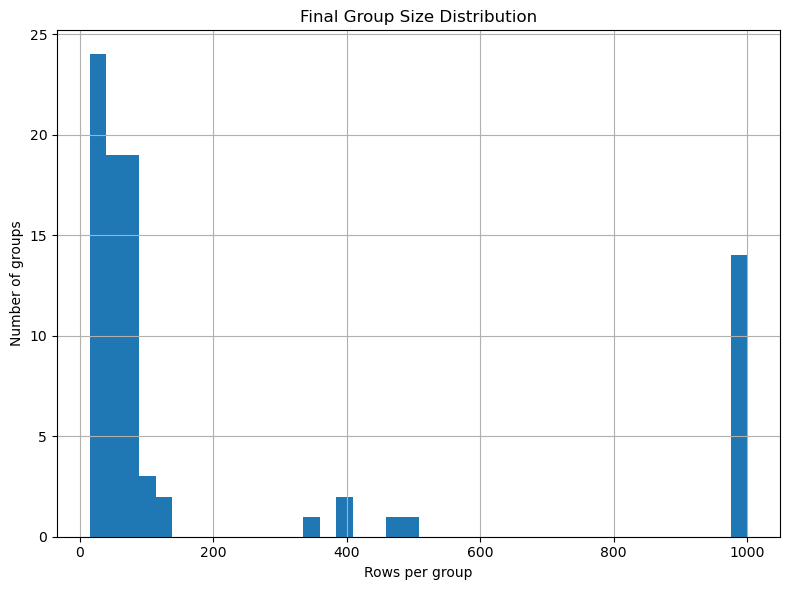

In [55]:
# Count how many samples remain
n_rows = len(X_final)
n_groups = pd.Series(groups_final).nunique()
group_counts_final = pd.Series(groups_final).value_counts()
group_summary = group_counts_final.describe()

# Print key info
print(f"✅ Final number of samples: {n_rows}")
print(f"✅ Final number of spatiotemporal groups: {n_groups}")
print("\n📊 Group Size Summary:")
print(group_summary)

# Optional: visualize
plt.figure(figsize=(8, 6))
group_counts_final.hist(bins=40)
plt.xlabel("Rows per group")
plt.ylabel("Number of groups")
plt.title("Final Group Size Distribution")
plt.tight_layout()
plt.show()

In [31]:
summarize_dataframe(X_encoded)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| Conversion.for.latitude                               | float64 |   69430 |          100   |        237 |
| prc1                                                  | float64 |   69430 |          100   |        268 |
| Conversion.for.longitude                              | float64 |   69430 |          100   |        237 |
| prc4                                                  | float64 |   69430 |          100   |        277 |
| prc5                                                  | float64 |   69430 |          100   |        274 |
| prc6                                                  | float64 |   69430 |          100   |        279 |
| prc7                                                  | float64 |   69430 |          100   |        279 |
| prc8                      

Define Training and testing set (prepare for agony)

In [33]:
# Define the seed for reproducibility
SEED = 42
np.random.seed(SEED)

#Drop the 'latitude and longitude' and columns from X_encoded
X_encoded = X_encoded.drop(columns=["lat", "lon", "Conversion.for.latitude", "Conversion.for.longitude"])


X_trainval, X_test, y_trainval, y_test, groups_trainval, groups_test = train_test_split(
    X_encoded,
    y,
    combined_groups,
    test_size=0.2,
    random_state=SEED,
    stratify=None  # Remove or set to None if group balance is poor
)

print(f"Train/Validation size: {X_trainval.shape[0]}")
print(f"Holdout test size:     {X_test.shape[0]}")


Train/Validation size: 55544
Holdout test size:     13886


In [34]:
# 🌲 BLOCK 5: XGBoost Regressor + Random Search + GroupKFold
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

cv = GroupKFold(n_splits=10)

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    missing=np.nan,
    n_jobs=os.cpu_count() - 1,
    random_state=SEED
)

param_dist = {
    "n_estimators": [100, 250, 500],
    "max_depth": [4, 6, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10]
}

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=cv.split(X_trainval, y_trainval, groups=groups_trainval),
    verbose=1,
    n_jobs=-1,
    random_state=SEED
)

search.fit(X_trainval, y_trainval)
best_model = search.best_estimator_

Fitting 10 folds for each of 20 candidates, totalling 200 fits


Final model running

Final model trained in 0.07 minutes.
Holdout Test Set Evaluation Metrics:
  MAE : 0.7883
  RMSE: 1.1356
  R²  : 0.7073


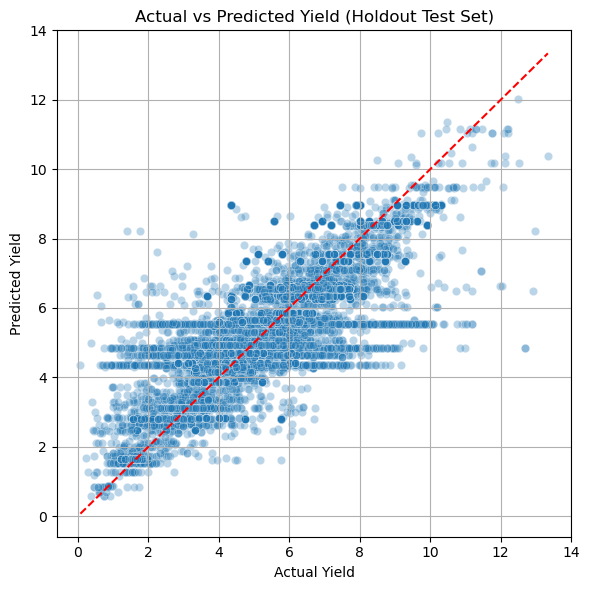

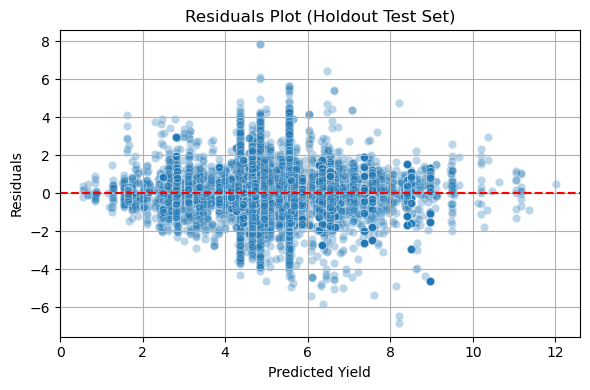

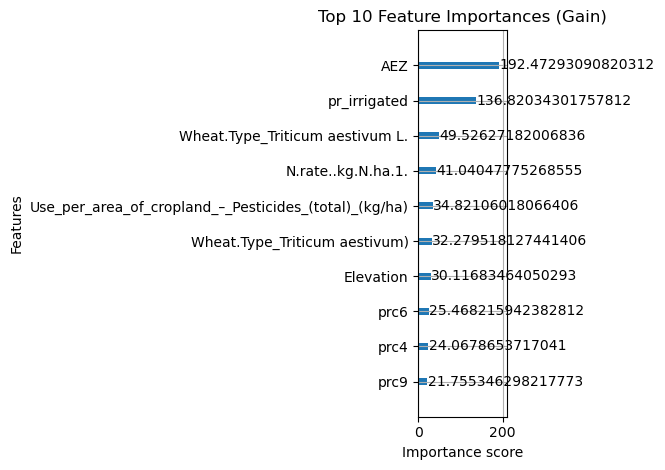

/tmp/ipykernel_40750/1929559830.py:66: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


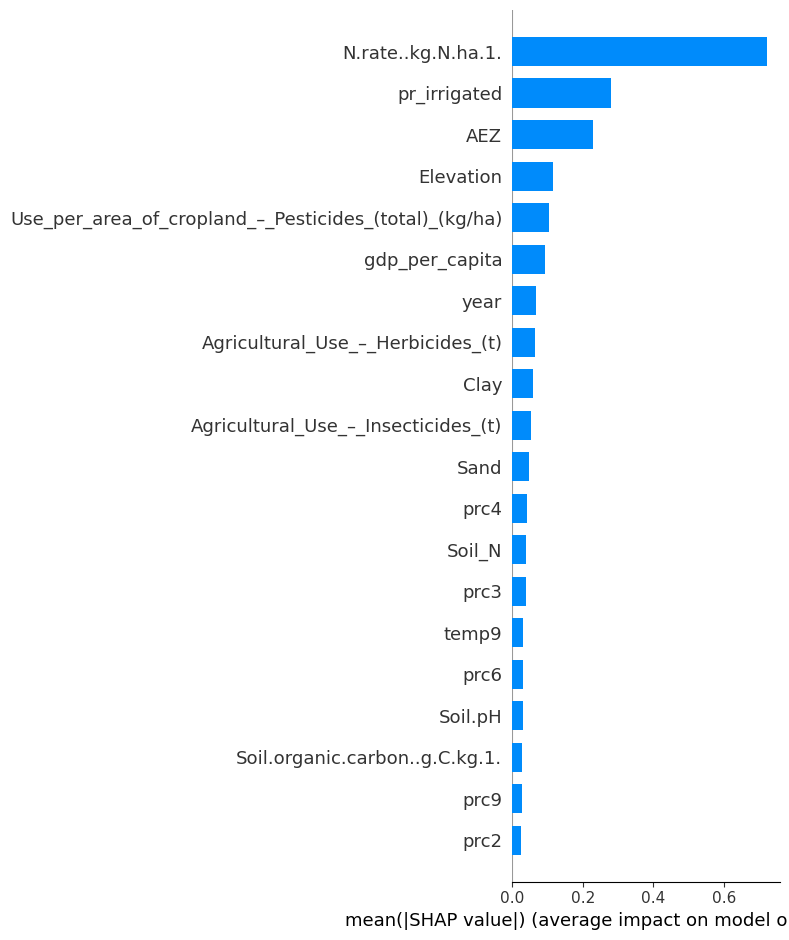

/tmp/ipykernel_40750/1929559830.py:69: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


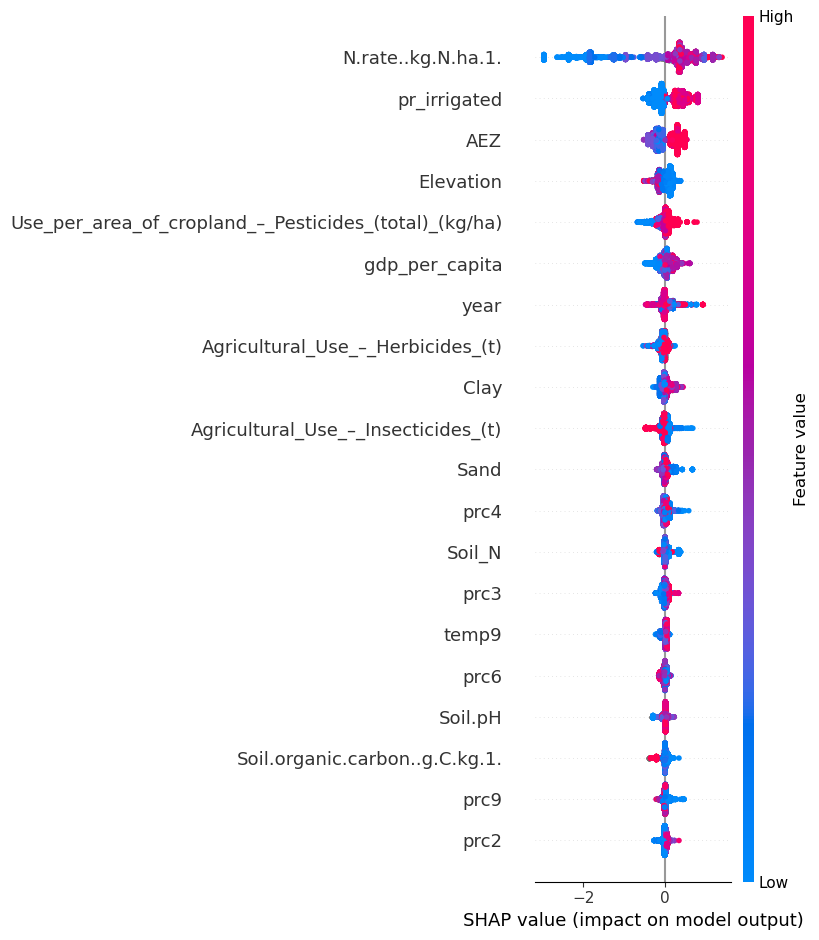

In [35]:
# Use best parameters from random search
best_params = search.best_params_

# Build final model
best_model = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    tree_method="hist",
    missing=np.nan,
    n_jobs=os.cpu_count() - 1,
    random_state=0
)

# Train on full training+validation set
start_time = time.time()
best_model.fit(X_trainval, y_trainval)
print(f"Final model trained in {(time.time() - start_time)/60:.2f} minutes.")

# Predict on holdout test set
y_pred = best_model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Holdout Test Set Evaluation Metrics:")
print(f"  MAE : {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²  : {r2:.4f}")

# Actual vs Predicted Plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield (Holdout Test Set)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals Plot
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.title("Residuals Plot (Holdout Test Set)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature Importance (XGBoost native)
xgb.plot_importance(best_model, importance_type='gain', max_num_features=10)
plt.title("Top 10 Feature Importances (Gain)")
plt.tight_layout()
plt.show()

# SHAP Explanation (on test data or a sample subset)
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

# SHAP Summary: Bar Plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

# SHAP Summary: Beeswarm Plot
shap.summary_plot(shap_values, X_test)

